# **Modul 2: Data Analysis**
# Data Visualization with Python

Gunakan dataset:
E-commerce dataset

**About Dataset**
Introduction

Analyzing the purchases of our customers for 1 year in America E-commerce dataset. How are their customer's online buying habits?

Columns name and meanings:

- Order_Date: The date the product was ordered.
- Aging: The time from the day the product is ordered to the day it is delivered.
- Customer_id: Unique id created for each customer.
- Gender: Gender of customer.
- Device_Type: The device the customer uses to actualize the transaction (Web/Mobile).
- Customer_Login_Type: The type the customer logged in. Such as Member, Guest etc.
- Product_Category: Product category
- Product: Product
- Sales: Total sales amount
- Quantity: Unit amount of product
- Discount: Percent discount rate
- Profit: Profit
- Shipping_cost: Shipping cost
- Order_Priority: Order priority. Such as critical, high etc.
- Payment_method: Payment method

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# scroll horizontal
pd.set_option('display.max_columns', 100)

# read exel
df = pd.read_csv('E-commerce Dataset.csv')
df.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


## **No.1**
### **What devices do my customers use to reach me?**

In [5]:
df['Device_Type'].unique()

array(['Web', 'Mobile'], dtype=object)

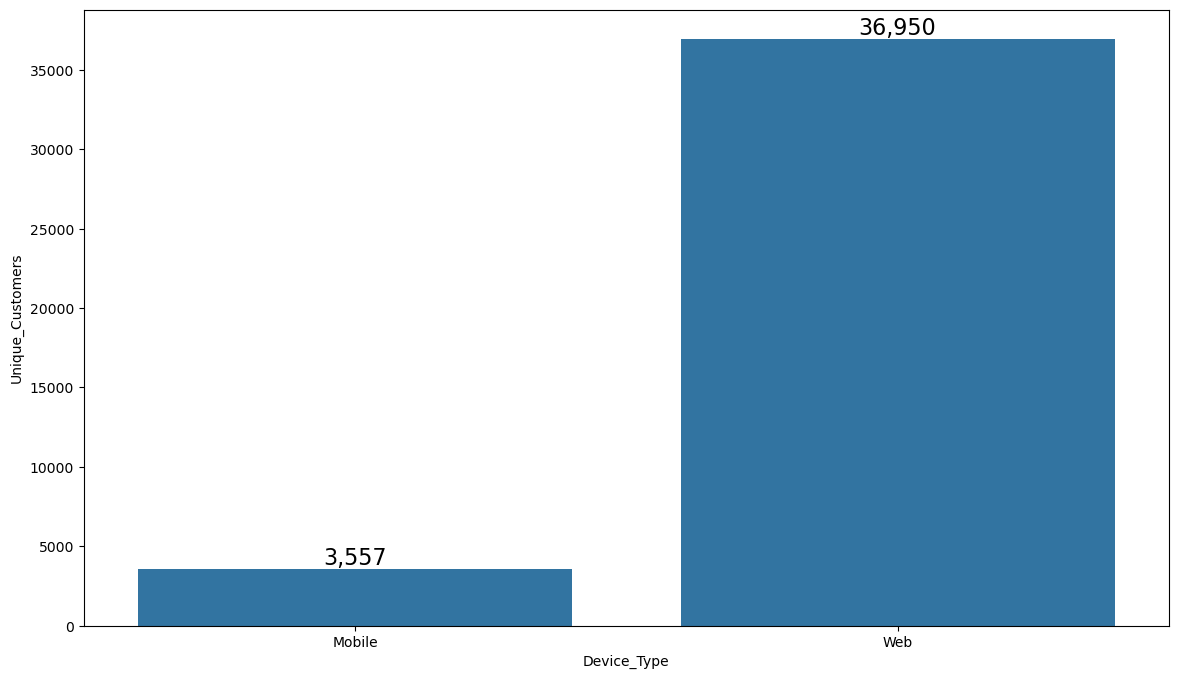

In [ ]:
customer_counts = df.groupby('Device_Type')['Customer_Id'].nunique().reset_index()
customer_counts.columns = ['Device_Type', 'Unique_Customers']

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=customer_counts, 
            x='Device_Type', 
            y='Unique_Customers')

for bar in ax.patches:
    ax.annotate(format(bar.get_height(), f',.0f'),
                (bar.get_x() + bar.get_width() / 2,
                bar.get_height()), 
                ha='center', 
                va='center',
                size=16, 
                xytext=(0, 8),
                textcoords='offset points')


## **No. 2**
### **How is the relationship between shipping costs and profit? Show this based on each product category!**  

<Axes: title={'center': 'Relationship between Shipping Costs and Profit'}, xlabel='Shipping_Cost', ylabel='Profit'>

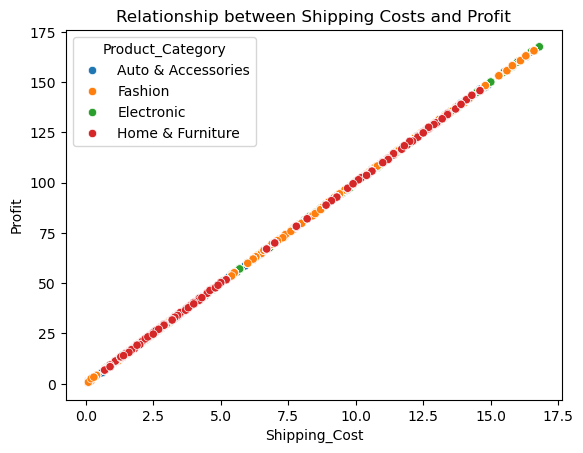

In [ ]:
plt.title('Relationship between Shipping Costs and Profit')
sns.scatterplot(data=df,
                x='Shipping_Cost',
                y='Profit',
                hue='Product_Category')

## **No.3**
### **What is the distribution of sales?**

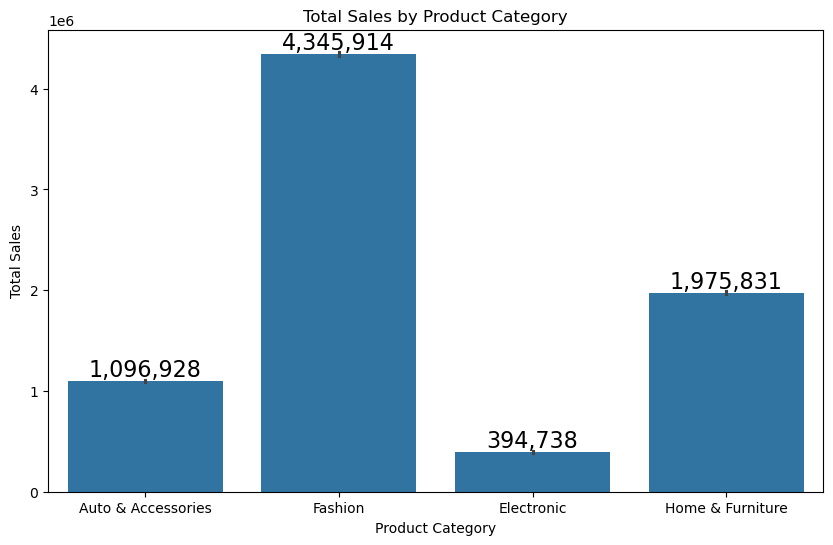

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, 
            x='Product_Category', 
            y='Sales', 
            estimator='sum')

for bar in ax.patches:
    ax.annotate(format(bar.get_height(), f',.0f'),
                (bar.get_x() + bar.get_width() / 2,
                bar.get_height()), 
                ha='center', 
                va='center',
                size=16, 
                xytext=(0, 8),
                textcoords='offset points')
    
plt.title('Total Sales by Product Category')
plt.ylabel('Total Sales')
plt.xlabel('Product Category')
plt.show()

## **No. 4**
### **Which product categories do I sell to whom? (Gender Distribution by Category or Product?)**


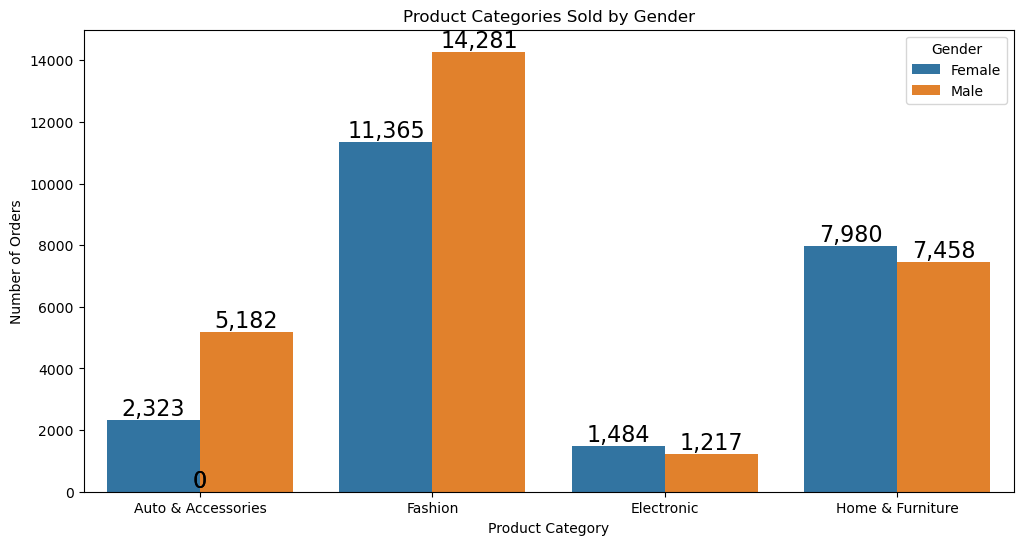

In [20]:
plt.figure(figsize=(12,6))
ax = sns.countplot(data=df, x='Product_Category', hue='Gender')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), f',.0f'),
                (bar.get_x() + bar.get_width() / 2,
                bar.get_height()), 
                ha='center', 
                va='center',
                size=16,
                xytext=(0, 8), 
                textcoords='offset points')
plt.title('Product Categories Sold by Gender')
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.show()

## **No.5**
### **Which login type do my customers prefer when shopping?**


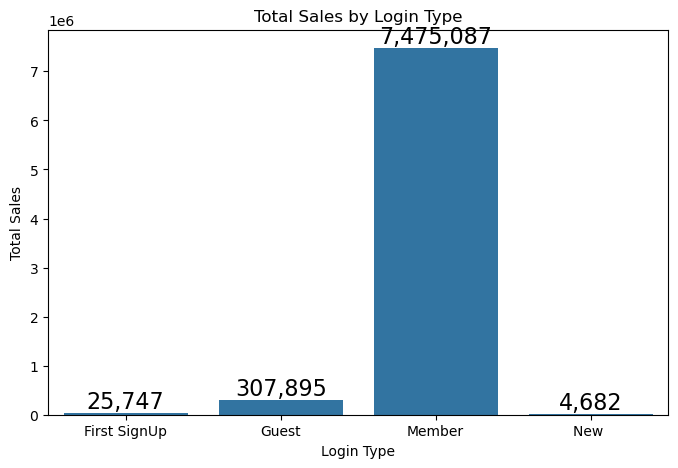

In [26]:
df_login_sales = df.groupby('Customer_Login_type')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=df_login_sales, 
            x='Customer_Login_type', 
            y='Sales')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), f',.0f'),
                (bar.get_x() + bar.get_width() / 2,
                bar.get_height()), 
                ha='center', 
                va='center',
                size=16,
                xytext=(0, 8), 
                textcoords='offset points')
plt.title('Total Sales by Login Type')
plt.xlabel('Login Type')
plt.ylabel('Total Sales')
plt.show()

## **No. 6**
### **How does the date and time affect my sales? (Sales Trend by Order date, Total sales by month, the days of week)**


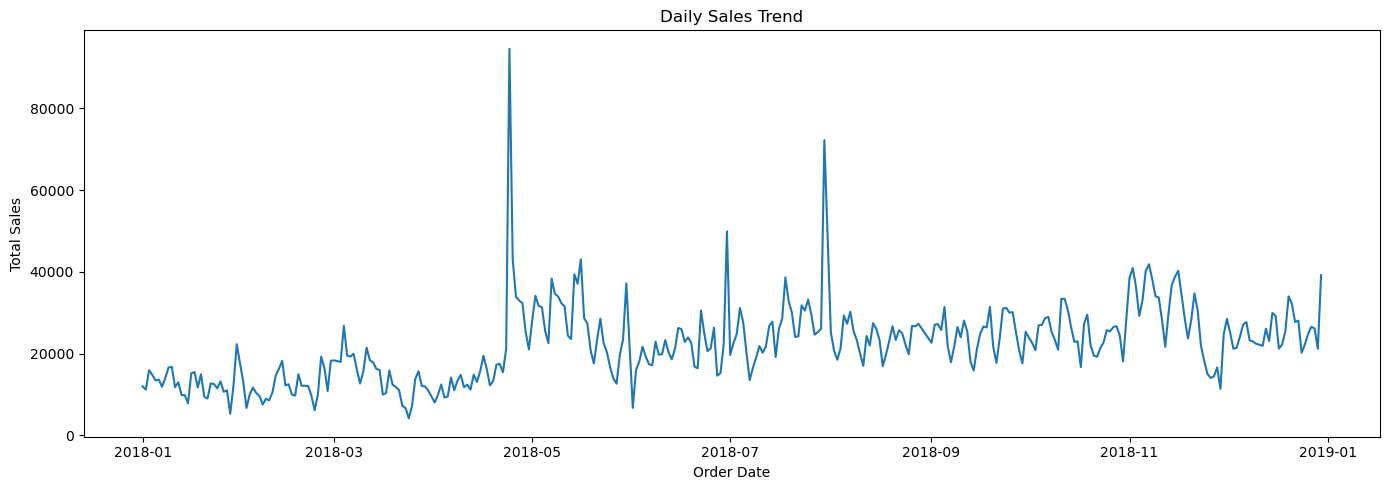

In [48]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

daily_sales = df.groupby('Order_Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_sales, x='Order_Date', y='Sales')
plt.title('Daily Sales Trend')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


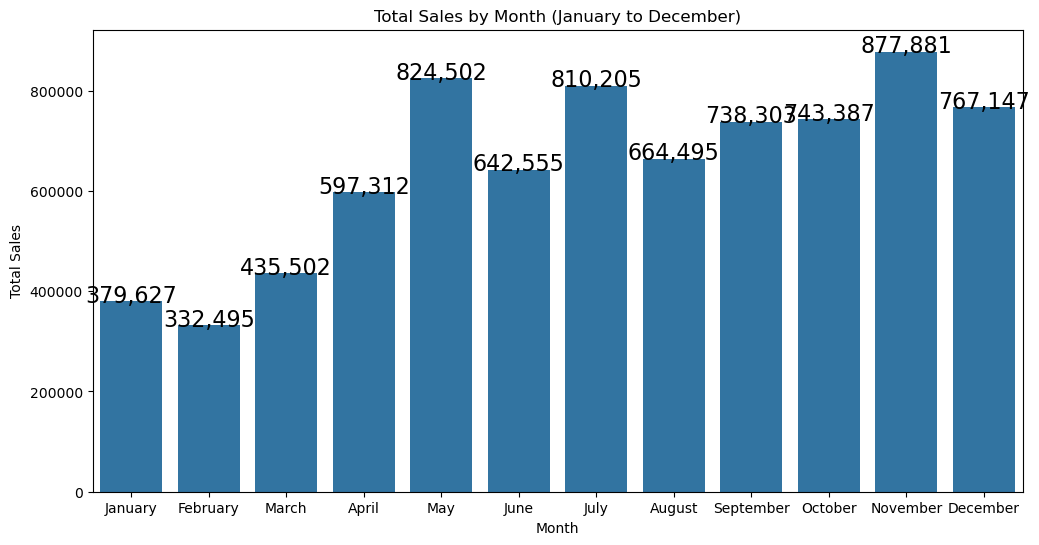

In [53]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Month_Name'] = df['Order_Date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = df.groupby('Order_Month_Name')['Sales'].sum().reindex(month_order).reset_index()
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=monthly_sales, x='Order_Month_Name', y='Sales')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), f',.0f'),
                (bar.get_x() + bar.get_width() / 2,
                bar.get_height()), 
                ha='center', 
                va='center',
                size=16,
                xytext=(0, 4), 
                textcoords='offset points')
plt.title('Total Sales by Month (January to December)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()


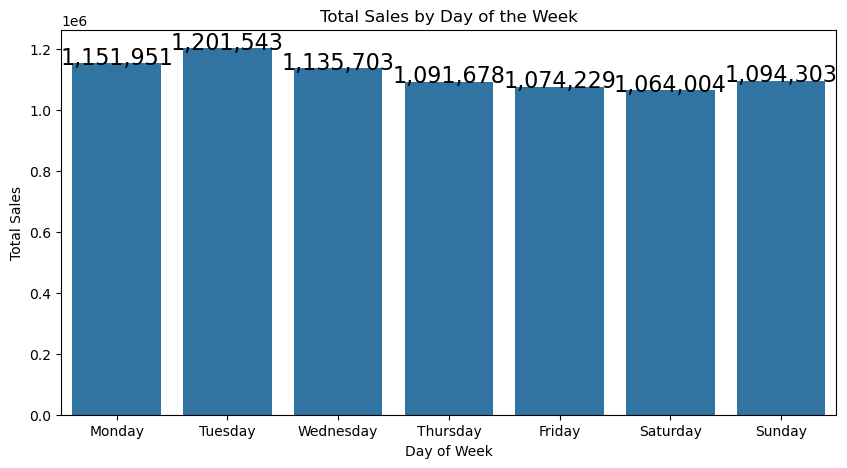

In [51]:
df['Day_of_Week'] = df['Order_Date'].dt.day_name()

dow_sales = df.groupby('Day_of_Week')['Sales'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=dow_sales, x='Day_of_Week', y='Sales')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), f',.0f'),
                (bar.get_x() + bar.get_width() / 2,
                bar.get_height()), 
                ha='center', 
                va='center',
                size=16,
                xytext=(0, 4), 
                textcoords='offset points')
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.show()


## **No.7**
### **From which product do I earn the most profit per unit?**


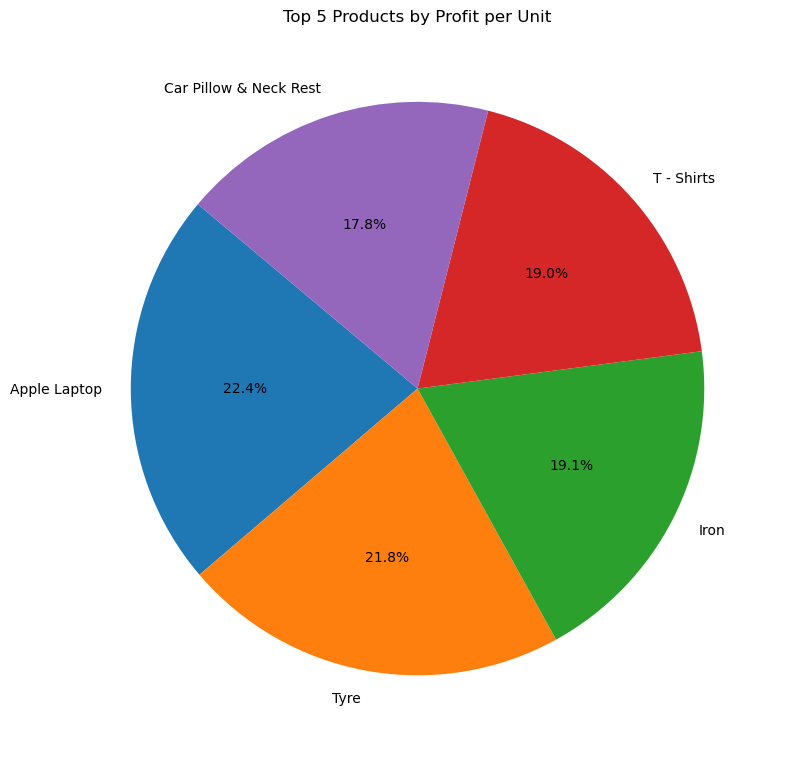

In [37]:
product_profit = df.groupby('Product')[['Profit', 'Quantity']].sum().reset_index()
product_profit['Profit_per_Unit'] = product_profit['Profit'] / product_profit['Quantity']
top_products = product_profit.sort_values(by='Profit_per_Unit', ascending=False).head(5)

plt.figure(figsize=(8, 8))
plt.pie(top_products['Profit_per_Unit'],
        labels=top_products['Product'],
        autopct='%1.1f%%',
        startangle=140)

plt.title('Top 5 Products by Profit per Unit')
plt.tight_layout()
plt.show()


## **No. 8**
### **How is my delivery speed and order priority?(Delivery Time distribution by order priority)**

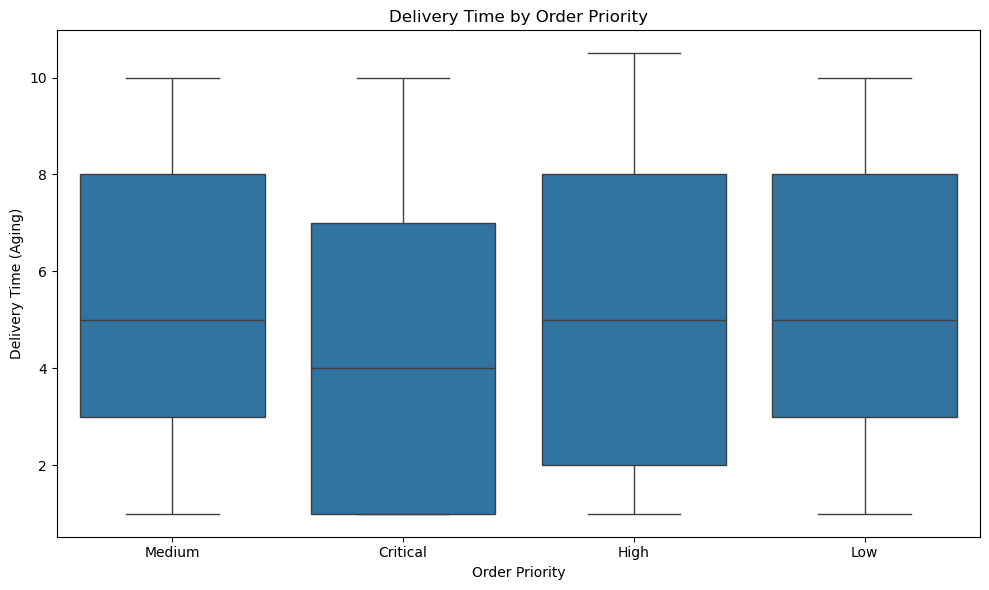

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Order_Priority', y='Aging')
plt.title('Delivery Time by Order Priority')
plt.xlabel('Order Priority')
plt.ylabel('Delivery Time (Aging)')
plt.tight_layout()
plt.show()
